In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve



In [2]:
URL_x_train ='../data/processed/x_train.csv'
URL_x_test ='../data/processed/x_test.csv'
URL_y_train ='../data/processed/y_train.csv'
URL_y_test ='../data/processed/y_test.csv'

In [3]:
x_test = pd.read_csv(URL_x_test)
x_train = pd.read_csv(URL_x_train)
y_test = pd.read_csv(URL_y_test)
y_train = pd.read_csv(URL_y_train)

In [4]:
model = LogisticRegression( class_weight='balanced', random_state=42, max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

/home/jeferssonvm/miniconda3/envs/especializacion_ia/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

[[55258  1393]
 [   12    83]]


In [5]:
ratio = len(y_train[y_train['class'] == 0]) / len(y_train[y_train['class'] == 1])
parametros = {
    'n_estimators':[100, 300, 500, 800, 1000],
    'learning_rate':[0.01, 0.05, 0.1, 0.2],
    'max_depth':[3, 5, 7, 10],
    'subsample':[0.6, 0.8, 1.0],
    'scale_pos_weight':[ratio]
}



random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'),
        param_distributions=parametros,
        n_iter=40,
        scoring='f1',
        cv=3,
        verbose=1,
        n_jobs=-1
)
random_search.fit(x_train, y_train.values.ravel())

print(f"Mejores parámetros encontrados: {random_search.best_params_}")
best_model = random_search.best_estimator_

# y_pred_xgb = modelXGB.predict(x_test)
# print('classification_report:')
# print(classification_report(y_test, y_pred_xgb))
# print('confusion_matrix:')
# print(confusion_matrix(y_test, y_pred_xgb))

# modelXGB = XGBClassifier(
#     scale_pos_weight=ratio,
#     random_state=42,
#     use_label_encoder=False,
#     eval_metric='logloss',
#     n_estimators=500,
#     learning_rate=0.05,
#     max_depth=5
# )
#modelXGB.fit(x_train, y_train)




Fitting 3 folds for each of 40 candidates, totalling 120 fits
Mejores parámetros encontrados: {'subsample': 0.6, 'scale_pos_weight': 599.4761904761905, 'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.1}



--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.78      0.86        95

    accuracy                           1.00     56746
   macro avg       0.98      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746

--- Matriz de Confusión ---
[[56648     3]
 [   21    74]]


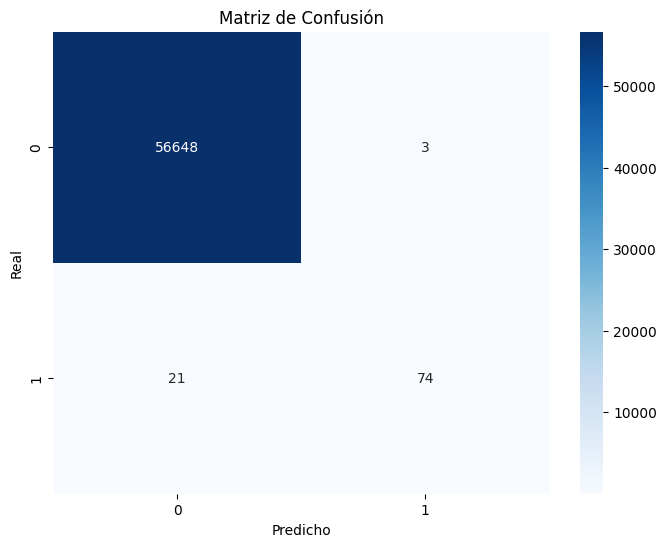

In [6]:
# 1. Realizar predicciones con el conjunto de prueba
y_pred = best_model.predict(x_test)

# 2. Generar el Reporte de Clasificación (Precision, Recall, F1, Accuracy)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# 3. Generar la Matriz de Confusión
print("--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Opcional: Visualización elegante con Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

--- Reporte con Umbral Ajustado (0.3) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.80      0.87        95

    accuracy                           1.00     56746
   macro avg       0.98      0.90      0.94     56746
weighted avg       1.00      1.00      1.00     56746



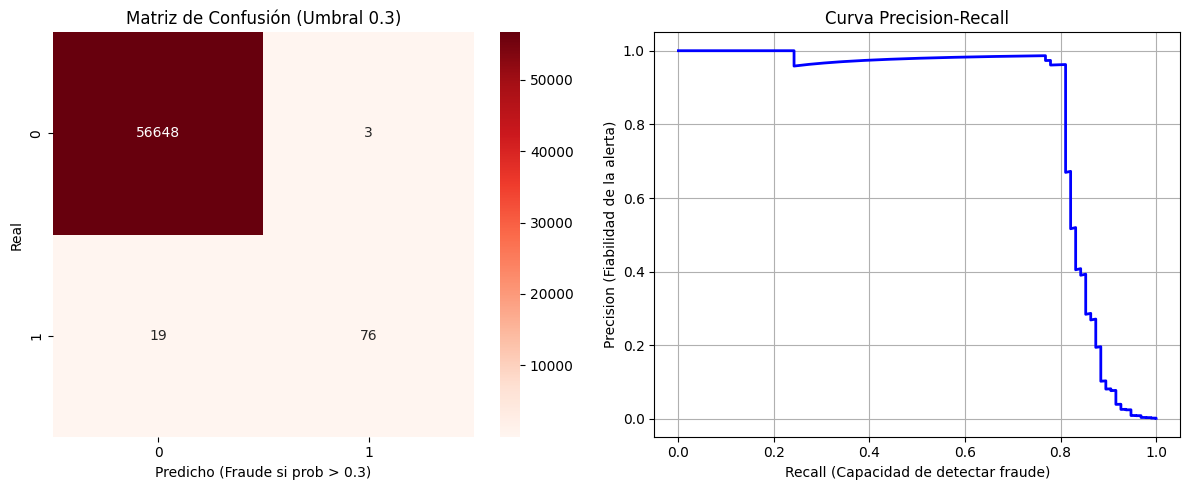

El umbral que matemáticamente optimiza el F1-Score es: 0.2885


In [7]:

# 1. Obtener las probabilidades (no solo la clase 0 o 1)

y_probs = best_model.predict_proba(x_test)[:, 1]


nuevo_umbral = 0.3
y_pred_ajustado = (y_probs >= nuevo_umbral).astype(int)

# 3. Reporte de resultados con el nuevo umbral
print(f"--- Reporte con Umbral Ajustado ({nuevo_umbral}) ---")
print(classification_report(y_test, y_pred_ajustado))

# 4. Matriz de Confusión Visual
cm_ajustada = confusion_matrix(y_test, y_pred_ajustado)

plt.figure(figsize=(12, 5))

# Matriz de Confusión
plt.subplot(1, 2, 1)
sns.heatmap(cm_ajustada, annot=True, fmt='d', cmap='Reds')
plt.title(f'Matriz de Confusión (Umbral {nuevo_umbral})')
plt.xlabel('Predicho (Fraude si prob > 0.3)')
plt.ylabel('Real')

# Curva Precision-Recall (La mejor para fraude)
plt.subplot(1, 2, 2)
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall (Capacidad de detectar fraude)')
plt.ylabel('Precision (Fiabilidad de la alerta)')
plt.title('Curva Precision-Recall')
plt.grid(True)

plt.tight_layout()
plt.show()

# 5. Funcipredictón para encontrar el "mejor" umbral basado en F1-score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"El umbral que matemáticamente optimiza el F1-Score es: {best_threshold:.4f}")

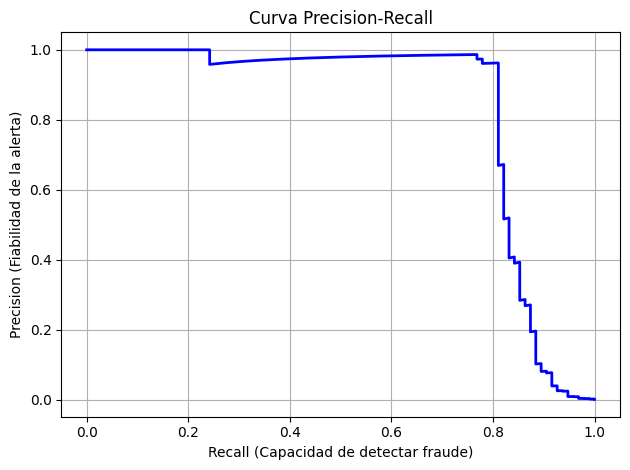

In [8]:
# Curva Precision-Recall (La mejor para fraude)

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall (Capacidad de detectar fraude)')
plt.ylabel('Precision (Fiabilidad de la alerta)')
plt.title('Curva Precision-Recall')
plt.grid(True)

plt.tight_layout()
plt.show()

Text(50.722222222222214, 0.5, 'Real')

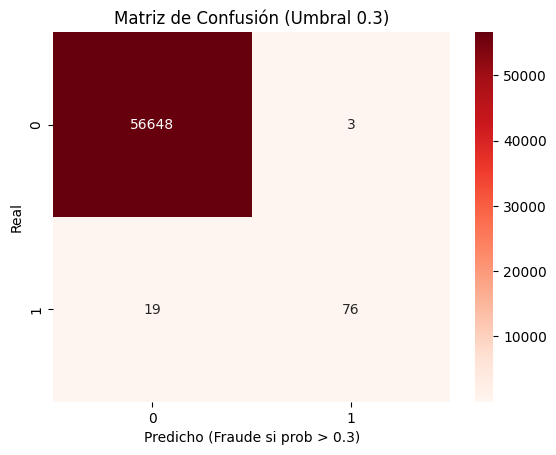

In [9]:
# Matriz de Confusión

sns.heatmap(cm_ajustada, annot=True, fmt='d', cmap='Reds')
plt.title(f'Matriz de Confusión (Umbral {nuevo_umbral})')
plt.xlabel('Predicho (Fraude si prob > 0.3)')
plt.ylabel('Real')

Se seleccionó un umbral de 0.3 para priorizar la detección de fraudes (Recall), aceptando un margen controlado de falsos positivos.

<Figure size 1000x1200 with 0 Axes>

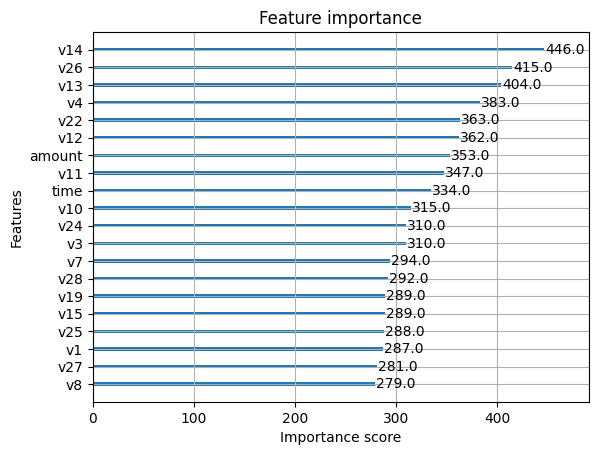

In [10]:
import matplotlib.pyplot as plt

# Esto te mostrará TODAS las variables que el modelo usó para ganar peso
plt.figure(figsize=(10,12))
from xgboost import plot_importance
plot_importance(best_model, max_num_features=20) 
plt.show()

In [11]:
import sys
print(sys.version)



3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]


In [12]:
import joblib
import os

# 1. Asegúrate de que la carpeta exista
models_dir = '../models/'
os.makedirs(models_dir, exist_ok=True)

# 2. Guarda el modelo
joblib.dump(best_model, os.path.join(models_dir, 'xgboost_fraud_model.joblib'))

print("Modelo guardado exitosamente como .joblib en la carpeta models/")

Modelo guardado exitosamente como .joblib en la carpeta models/


* Segun el analisis del dataset, se identifico un desbalance muy grande entre clases, por lo cual la regresion logistica no era la mejor opcion como modelo principal. Sin embargo, se implemento para tener una base de comparacion y realizar experimentacion inicial.
* La precision del modelo es de 96%, indicando que genera muy pocos falsos positivos, evitando posibles molestias a los clientes y manteniendo una buena capacidad de deteccion.

* El modelo presenta un recall de 0.80, indicando que aunque el modelo es preciso para detectar fraude, aun existen algunos casos que no son detectados. Este resultado es esperado y aceptable debido al alto desbalance presente en el dataset. Aunque es posible aumentar el recall, esto generalmente provoca una disminucion en la precision, lo que podria incrementar costos operativos y generar molestias a los clientes debido a falsas alarmas.
* El F1-Score de 0.87 indica que el modelo mantiene un buen equilibrio entre precision y recall, conservando una adecuada capacidad de deteccion sin sacrificar la confiabilidad de las predicciones.